# 06 -- Fine-Tuning a Small Model with LoRA

Same `.venv`, notebooks 00-05 untouched. This notebook adds two new dependencies (`transformers`, `peft`) -- `torch` is already installed from the CTSM notebooks. **This notebook does not fine-tune Foundation-Sec-8B.** Fine-tuning updates every parameter's gradient at least once; an 8B model's optimizer state alone would dwarf this Mac's 16GB of unified memory. Instead this notebook fine-tunes a small (494M-parameter) instruction model, chosen and verified for this hardware in Section 2 *before* any training happens.

**Goal:** learn what fine-tuning actually is, why LoRA makes it practical on a laptop, and -- honestly -- whether it helps on a small, narrow, synthetic task, without overclaiming in either direction.

## Section 1 -- What fine-tuning actually is

Three techniques for getting a foundation model to do what you want, and the one distinction that separates them:

| Technique | What changes |
|---|---|
| **Prompting** (notebooks 03/04) | Nothing. The model's weights are untouched; only the text handed to it at inference time changes. |
| **RAG** (notebook 05) | Nothing. Same as prompting -- retrieval just changes *what text* gets put in the prompt. |
| **Fine-tuning** (this notebook) | The model's weights (or, with LoRA, a small set of added adapter weights) are actually updated via gradient descent on new examples. |

**Why this distinction matters.** Prompting and RAG are reversible and instantaneous -- change the prompt or the retrieved documents, and the model's behavior changes on the very next call, with zero training cost. Fine-tuning is neither: it requires a training run, it produces a new model artifact that has to be versioned and evaluated (Section 13), and its effects are baked in until the next training run. That's a real product tradeoff, not just a technical one -- it's the difference between editing a config file and shipping a new build.

## Section 2 -- Choosing a small model (verified before downloading anything else)

**Model: `Qwen/Qwen2.5-0.5B-Instruct`.**

- **Parameter count:** 494M (verified below by summing `model.parameters()`, not just quoted from the model card) -- comfortably inside the 100M-1B range, and nowhere near Foundation-Sec-8B's 8 billion.
- **Expected memory:** weights alone are ~988MB on disk (bfloat16). Loaded in float32 for training stability, that's roughly ~2GB resident. LoRA training only needs gradients and optimizer state for the small adapter parameters (Section 6), not the full 494M -- so total peak memory stays a few GB, an order of magnitude under this Mac's 16GB.
- **Expected training time:** ~40 examples, a handful of epochs, on a model this size -- low single-digit minutes on Apple Silicon, measured for real in Section 7.
- **Apple MPS support:** yes -- Qwen2 is a standard `transformers` architecture with no custom ops that require CUDA. Confirmed below with a real forward *and* backward pass on the `mps` device, since training (not just inference) is what actually matters for this notebook.

License: Apache 2.0 -- no usage restrictions for this kind of local experimentation.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import time
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

t0 = time.time()
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float32).to(device)
print(f"Model loaded in {time.time() - t0:.1f}s (first run downloads ~988MB, cached afterward)")

total_params = sum(p.numel() for p in model.parameters())
print(f"Verified parameter count: {total_params:,} ({total_params / 1e6:.1f}M)")

# Real forward + backward smoke test on MPS -- confirms training, not just inference, works here
sample_prompt = tokenizer.apply_chat_template(
    [{"role": "user", "content": "Say OK."}], tokenize=False, add_generation_prompt=True
)
sample_ids = tokenizer(sample_prompt + " OK" + tokenizer.eos_token, return_tensors="pt").input_ids.to(device)
t0 = time.time()
out = model(input_ids=sample_ids, labels=sample_ids)
out.loss.backward()
model.zero_grad()
print(f"Forward+backward on {device} confirmed working (loss={out.loss.item():.2f}, {time.time() - t0:.2f}s)")
print("\nProceeding: this model fits comfortably on this hardware.")

Device: mps


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/290 [00:00<01:39,  2.90it/s]

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 785.75it/s]

Model loaded in 1.5s (first run downloads ~988MB, cached afterward)
Verified parameter count: 494,032,768 (494.0M)


Forward+backward on mps confirmed working (loss=5.42, 0.47s)

Proceeding: this model fits comfortably on this hardware.


## Section 3 -- A small security instruction dataset

A single narrow task: classify a security event as **BENIGN**, **SUSPICIOUS**, or **MALICIOUS**. Every example is fully synthetic, built from short templates with variable slot-fills (a host name, a username, a timestamp) -- clearly labeled as synthetic, no real data anywhere.

**Why a narrow task for a first fine-tuning experiment?** A first fine-tuning run should isolate one clear, measurable question -- "can this small amount of training data teach a small model to reliably do this one thing" -- rather than trying to teach broad, open-ended security reasoning at the same time. A narrow task makes success or failure legible: either the classification accuracy moved in a checkable way or it didn't. A broad task would make it much harder to tell whether a poor result is due to the fine-tuning approach or simply an underspecified goal.

In [2]:
INSTRUCTION = "Classify the following security event as BENIGN, SUSPICIOUS, or MALICIOUS. Respond with exactly one of those three words."

HOSTS = ["WKSTN-011", "FS-04", "APP-SRV-02"]
USERS = ["jsmith", "agarcia", "tlee"]
TIMES = ["02:00 UTC", "03:00 UTC", "01:30 UTC"]
CITY_PAIRS = [("Chicago", "Hanoi"), ("New York", "Manila"), ("London", "Jakarta")]

# Each (label, template_id, template) -- template_id lets us hold out an ENTIRE template
# for validation, not just individual filled-in examples, so validation tests a phrasing
# pattern the model never saw in training rather than just new names in a familiar sentence.
TEMPLATES = [
    ("BENIGN", "B1", "Scheduled backup job on {host} completed successfully at {time} with no errors."),
    ("BENIGN", "B2", "Admin '{user}' logged into {host} from the internal corporate network during business hours."),
    ("BENIGN", "B3", "User '{user}' reset their own password using the self-service portal, as expected."),
    ("BENIGN", "B4", "Routine security patch was deployed to {host} with no errors or unexpected behavior."),
    ("BENIGN", "B5_HELD_OUT", "User '{user}' accessed the internal wiki from their usual office workstation."),
    ("SUSPICIOUS", "S1", "User '{user}' failed to log in 5 times within 10 minutes before succeeding on the 6th attempt."),
    ("SUSPICIOUS", "S2", "A PowerShell command with slightly obfuscated syntax ran on {host}, but no further unusual activity followed."),
    ("SUSPICIOUS", "S3", "User '{user}' logged in from a country they have not used before, though the session ended with no further activity."),
    ("SUSPICIOUS", "S4", "An outbound connection to an unfamiliar external IP was observed from {host}, occurring only once."),
    ("SUSPICIOUS", "S5_HELD_OUT", "User '{user}' was added to a new internal security group outside the normal weekly change window."),
    ("MALICIOUS", "M1", "User '{user}' logged in from {city1} and then again from {city2} nine minutes later, a distance impossible to travel in that time."),
    ("MALICIOUS", "M2", "Host {host} executed a PowerShell command with a hidden window and base64-encoded payload, followed by an outbound connection to a known malicious IP."),
    ("MALICIOUS", "M3", "Standard user '{user}' was added to the Domain Admins group immediately after a known vulnerability was exploited on {host}."),
    ("MALICIOUS", "M4", "Host {host} connected to an IP address listed on multiple threat intelligence feeds as an active command-and-control server."),
    ("MALICIOUS", "M5_HELD_OUT", "A file server showed mass file renames to an unfamiliar extension along with shadow copy deletion, consistent with ransomware."),
]

examples = []
for label, template_id, template in TEMPLATES:
    for i in range(3):
        fill = {"host": HOSTS[i], "user": USERS[i], "time": TIMES[i], "city1": CITY_PAIRS[i][0], "city2": CITY_PAIRS[i][1]}
        text = template.format(**fill)
        examples.append({
            "instruction": INSTRUCTION,
            "input": text,
            "expected_output": label,
            "template_id": template_id,
        })

print(f"{len(examples)} synthetic examples generated across {len(TEMPLATES)} templates (3 classes).")
print(f"Class balance: " + ", ".join(f"{lbl}={sum(1 for e in examples if e['expected_output']==lbl)}" for lbl in ['BENIGN','SUSPICIOUS','MALICIOUS']))

45 synthetic examples generated across 15 templates (3 classes).
Class balance: BENIGN=15, SUSPICIOUS=15, MALICIOUS=15


## Section 4 -- Train / validation split

Examples are split by **template ID**, not shuffled randomly: every `_HELD_OUT` template's examples go to validation, everything else goes to training. This is a reproducible, non-random split (rerunning this notebook always produces the same split) and it specifically prevents leakage: a random per-example split could put two near-identical instantiations of the *same template* (same sentence, different username) on both sides of the split, letting the model "pass" validation by memorizing surface phrasing rather than learning the underlying pattern.

**Why held-out evaluation data matters at all:** without it, the only way to check whether fine-tuning worked would be to look at performance on the very data it trained on -- which just measures memorization, not learning. A model can trivially get 100% on its own training set while being useless on anything else.

In [3]:
train_examples = [e for e in examples if not e["template_id"].endswith("_HELD_OUT")]
val_examples = [e for e in examples if e["template_id"].endswith("_HELD_OUT")]

train_templates = set(e["template_id"] for e in train_examples)
val_templates = set(e["template_id"] for e in val_examples)
assert not (train_templates & val_templates), "Template leakage between train and validation!"

print(f"Training examples  : {len(train_examples)} (from templates {sorted(train_templates)})")
print(f"Validation examples: {len(val_examples)} (from templates {sorted(val_templates)})")
print("Confirmed: zero template overlap between training and validation.")

Training examples  : 36 (from templates ['B1', 'B2', 'B3', 'B4', 'M1', 'M2', 'M3', 'M4', 'S1', 'S2', 'S3', 'S4'])
Validation examples: 9 (from templates ['B5_HELD_OUT', 'M5_HELD_OUT', 'S5_HELD_OUT'])
Confirmed: zero template overlap between training and validation.


## Section 5 -- Base model performance, before any fine-tuning

We ask the un-modified base model to classify every validation example, using Qwen's own chat template (the format it was already instruction-tuned to expect) so this is a fair baseline, not a strawman. This is the number every later result gets compared against.

**Why a baseline is essential:** without measuring "how good is it before," there is no way to know whether fine-tuning changed anything, let alone improved it. A post-training accuracy number in isolation is meaningless -- 80% is a regression if the baseline was already 95%, and a big win if the baseline was 20%.

In [4]:
LABELS = ["BENIGN", "SUSPICIOUS", "MALICIOUS"]


def build_prompt(instruction, input_text):
    messages = [{"role": "user", "content": f"{instruction}\n\nSecurity event: {input_text}"}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


def predict_label(model_to_use, example, max_new_tokens=8):
    prompt = build_prompt(example["instruction"], example["input"])
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model_to_use.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=tokenizer.pad_token_id,
        )
    generated = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    generated_upper = generated.upper()
    for label in LABELS:
        if label in generated_upper:
            return label, generated
    return "UNPARSEABLE", generated


def evaluate(model_to_use, dataset):
    results = []
    for ex in dataset:
        predicted, raw = predict_label(model_to_use, ex)
        results.append({**ex, "predicted": predicted, "raw_generation": raw, "correct": predicted == ex["expected_output"]})
    accuracy = sum(1 for r in results if r["correct"]) / len(results)
    return results, accuracy


base_val_results, base_val_accuracy = evaluate(model, val_examples)
print(f"Base model validation accuracy: {base_val_accuracy:.0%} ({sum(1 for r in base_val_results if r['correct'])}/{len(base_val_results)})\n")
for r in base_val_results:
    mark = "OK " if r["correct"] else "ERR"
    print(f"[{mark}] expected={r['expected_output']:<12} predicted={r['predicted']:<12} raw={r['raw_generation'][:50]!r}")

Base model validation accuracy: 33% (3/9)

[ERR] expected=BENIGN       predicted=MALICIOUS    raw='MALICIOUS'
[ERR] expected=BENIGN       predicted=MALICIOUS    raw='MALICIOUS'
[ERR] expected=BENIGN       predicted=MALICIOUS    raw='MALICIOUS'
[ERR] expected=SUSPICIOUS   predicted=MALICIOUS    raw='MALICIOUS'
[ERR] expected=SUSPICIOUS   predicted=MALICIOUS    raw='MALICIOUS'
[ERR] expected=SUSPICIOUS   predicted=MALICIOUS    raw='MALICIOUS'
[OK ] expected=MALICIOUS    predicted=MALICIOUS    raw='MALICIOUS'
[OK ] expected=MALICIOUS    predicted=MALICIOUS    raw='MALICIOUS'
[OK ] expected=MALICIOUS    predicted=MALICIOUS    raw='MALICIOUS'


## Section 6 -- LoRA

**LoRA = Low-Rank Adaptation.** Instead of updating all 494M of the model's original weights, LoRA freezes every original weight and, at a chosen set of layers, adds a small pair of new matrices whose product approximates the *change* the model needs to learn. Only those new matrices are trained; everything else stays exactly as it was.

- **Frozen base model** -- the original 494M parameters never move. Nothing about the model's general knowledge or language ability is at risk of being damaged by this small training run.
- **Trainable adapter parameters** -- the new, small matrices added at each targeted layer. These are the only things gradient descent actually updates.
- **Rank (`r`)** -- how large those added matrices are. A higher rank can represent a more complex change but adds more trainable parameters; a lower rank is more constrained but far cheaper. We use `r=8`, a common small-task default.
- **Alpha** -- a scaling factor applied to the adapter's contribution (`alpha / r` scales how strongly the adapter's output is added back into the model). We use `alpha=16` (twice the rank, a standard convention).
- **Dropout** -- randomly zeroes out a fraction of the adapter's activations during training only, as a mild regularizer against overfitting a small dataset. We use `0.05`.

In [5]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none",
    task_type="CAUSAL_LM",
)

peft_model = get_peft_model(model, lora_config)
peft_model.print_trainable_parameters()

trainable = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in peft_model.parameters())
print(f"\nTotal parameters    : {total:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"Percentage trainable: {trainable / total:.3%}")

trainable params: 1,081,344 || all params: 495,114,112 || trainable%: 0.2184

Total parameters    : 495,114,112
Trainable parameters: 1,081,344
Percentage trainable: 0.218%


## Section 7 -- Fine-tuning

A plain, hand-written training loop (no `Trainer` abstraction) so every step is visible. Settings, in PM-friendly terms:

- **Batch size 1, with gradient accumulation over 4 examples** -- rather than processing 4 examples at once (which requires padding logic to handle different lengths), we process them one at a time and add up their gradients before taking one optimization step. The practical effect is the same as a batch size of 4; the code is simpler.
- **4 epochs** -- the training set (36 examples) is shown to the model 4 times. Few enough to finish in minutes on this hardware and to leave clear room to observe overfitting (Section 9) if it happens.
- **Learning rate 2e-4** -- how large a step each update takes. This is a deliberately small, conservative value typical for LoRA (LoRA's added parameters are more sensitive to overshooting than one might expect from their small size).
- **Prompt-token masking** -- the loss is computed only on the model's response tokens (the label word), not on the instruction/input tokens that were fed in. This is standard practice for instruction fine-tuning: without it, the model would waste capacity learning to predict its own inputs back to itself.

In [6]:
EPOCHS = 4
ACCUMULATION_STEPS = 4
LEARNING_RATE = 2e-4

trainable_params = [p for p in peft_model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=LEARNING_RATE)


def example_loss(model_to_use, example):
    prompt = build_prompt(example["instruction"], example["input"])
    full_text = prompt + " " + example["expected_output"] + tokenizer.eos_token
    prompt_ids = tokenizer(prompt, return_tensors="pt").input_ids
    full_ids = tokenizer(full_text, return_tensors="pt").input_ids
    labels = full_ids.clone()
    labels[:, :prompt_ids.shape[1]] = -100  # mask the prompt -- only train on the response
    full_ids, labels = full_ids.to(device), labels.to(device)
    return model_to_use(input_ids=full_ids, labels=labels).loss


def average_loss(model_to_use, dataset):
    with torch.no_grad():
        return sum(example_loss(model_to_use, ex).item() for ex in dataset) / len(dataset)


train_losses, val_losses = [], []
training_start = time.time()

for epoch in range(1, EPOCHS + 1):
    peft_model.train()
    epoch_loss_sum = 0.0
    optimizer.zero_grad()
    for i, ex in enumerate(train_examples):
        loss = example_loss(peft_model, ex) / ACCUMULATION_STEPS
        loss.backward()
        epoch_loss_sum += loss.item() * ACCUMULATION_STEPS
        if (i + 1) % ACCUMULATION_STEPS == 0 or (i + 1) == len(train_examples):
            optimizer.step()
            optimizer.zero_grad()

    peft_model.eval()
    train_loss = epoch_loss_sum / len(train_examples)
    val_loss = average_loss(peft_model, val_examples)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch}/{EPOCHS}: train_loss={train_loss:.3f}  val_loss={val_loss:.3f}")

training_time = time.time() - training_start
print(f"\nTotal training time: {training_time:.1f}s for {EPOCHS} epochs over {len(train_examples)} examples")

Epoch 1/4: train_loss=2.094  val_loss=0.652


Epoch 2/4: train_loss=0.278  val_loss=0.281


Epoch 3/4: train_loss=0.266  val_loss=0.197


Epoch 4/4: train_loss=0.100  val_loss=0.211

Total training time: 19.5s for 4 epochs over 36 examples


## Section 8 -- Evaluation: base model vs. LoRA fine-tuned model

Same held-out validation set, same prediction function, now run through the fine-tuned adapters. The base-model numbers are exactly the ones already computed in Section 5, before any training happened -- not re-run, so there's no chance of accidentally comparing against a moving target.

In [7]:
peft_model.eval()
lora_val_results, lora_val_accuracy = evaluate(peft_model, val_examples)

print(f"Base model accuracy (Section 5): {base_val_accuracy:.0%}")
print(f"LoRA model accuracy            : {lora_val_accuracy:.0%}\n")

changed = []
for base_r, lora_r in zip(base_val_results, lora_val_results):
    if base_r["predicted"] != lora_r["predicted"]:
        changed.append((base_r, lora_r))

print(f"{len(changed)}/{len(val_examples)} validation predictions changed after fine-tuning:\n")
for base_r, lora_r in changed:
    print(f"  input: {base_r['input'][:70]}...")
    print(f"    expected={base_r['expected_output']}  base={base_r['predicted']} -> lora={lora_r['predicted']}")

if lora_val_accuracy > base_val_accuracy:
    print(f"\nResult: fine-tuning improved validation accuracy on this task ({base_val_accuracy:.0%} -> {lora_val_accuracy:.0%}).")
elif lora_val_accuracy < base_val_accuracy:
    print(f"\nResult: fine-tuning REDUCED validation accuracy on this task ({base_val_accuracy:.0%} -> {lora_val_accuracy:.0%}). Not claiming an improvement.")
else:
    print(f"\nResult: fine-tuning did not change validation accuracy on this task ({base_val_accuracy:.0%}).")

Base model accuracy (Section 5): 33%
LoRA model accuracy            : 67%

6/9 validation predictions changed after fine-tuning:

  input: User 'jsmith' accessed the internal wiki from their usual office works...
    expected=BENIGN  base=MALICIOUS -> lora=SUSPICIOUS
  input: User 'agarcia' accessed the internal wiki from their usual office work...
    expected=BENIGN  base=MALICIOUS -> lora=SUSPICIOUS
  input: User 'tlee' accessed the internal wiki from their usual office worksta...
    expected=BENIGN  base=MALICIOUS -> lora=SUSPICIOUS
  input: User 'jsmith' was added to a new internal security group outside the n...
    expected=SUSPICIOUS  base=MALICIOUS -> lora=SUSPICIOUS
  input: User 'agarcia' was added to a new internal security group outside the ...
    expected=SUSPICIOUS  base=MALICIOUS -> lora=SUSPICIOUS
  input: User 'tlee' was added to a new internal security group outside the nor...
    expected=SUSPICIOUS  base=MALICIOUS -> lora=SUSPICIOUS

Result: fine-tuning improved 

In [8]:
import numpy as np


def confusion_matrix(results, labels):
    idx = {label: i for i, label in enumerate(labels)}
    matrix = np.zeros((len(labels), len(labels)), dtype=int)
    for r in results:
        true_i = idx.get(r["expected_output"])
        pred_i = idx.get(r["predicted"])
        if pred_i is None:  # UNPARSEABLE prediction -- still count it against the true row
            continue
        matrix[true_i, pred_i] += 1
    return matrix


cm_base = confusion_matrix(base_val_results, LABELS)
cm_lora = confusion_matrix(lora_val_results, LABELS)
print("Base model confusion matrix (rows=expected, cols=predicted):")
print(LABELS)
print(cm_base)
print("\nLoRA model confusion matrix (rows=expected, cols=predicted):")
print(LABELS)
print(cm_lora)

Base model confusion matrix (rows=expected, cols=predicted):
['BENIGN', 'SUSPICIOUS', 'MALICIOUS']
[[0 0 3]
 [0 0 3]
 [0 0 3]]

LoRA model confusion matrix (rows=expected, cols=predicted):
['BENIGN', 'SUSPICIOUS', 'MALICIOUS']
[[0 3 0]
 [0 3 0]
 [0 0 3]]


## Section 9 -- Overfitting

If training loss keeps falling while validation loss flattens out or starts rising, that's the classic overfitting signature: the model is increasingly good at the specific 36 training examples and increasingly less able to generalize past them. With a dataset this small (36 training examples), overfitting risk is real and worth checking directly rather than assuming it away.

What tends to cause it here specifically:
- **Too many epochs** -- showing the model the same 36 examples too many times lets it start memorizing exact phrasing instead of the underlying pattern.
- **Too little training data** -- 36 examples is enough to demonstrate the mechanics of LoRA, not enough to guarantee robust generalization.
- **An overly narrow dataset** -- only 5 templates per class (4 in training) means the model has limited phrasing variety to generalize from.
- **Learning rate** -- too high a learning rate can let the model lurch toward memorizing individual examples rather than gradually learning a shared pattern.

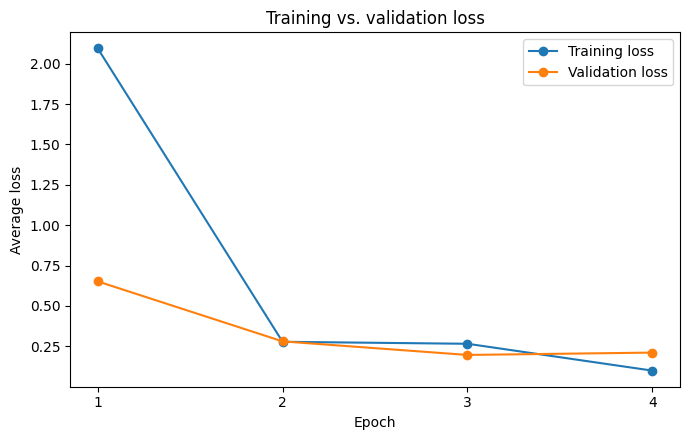

Validation loss's best epoch was 3 of 4; it rose afterward (0.197 -> 0.211) -- a mild overfitting signal.


In [9]:
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("..") / "results"
RESULTS_DIR.mkdir(exist_ok=True)

epochs_range = list(range(1, EPOCHS + 1))
plt.figure(figsize=(7, 4.5))
plt.plot(epochs_range, train_losses, marker="o", label="Training loss")
plt.plot(epochs_range, val_losses, marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Average loss")
plt.title("Training vs. validation loss")
plt.xticks(epochs_range)
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "finetuning_loss.png", dpi=150)
plt.show()

if val_losses[-1] > min(val_losses):
    print(f"Validation loss's best epoch was {val_losses.index(min(val_losses)) + 1} of {EPOCHS};"
          f" it rose afterward ({min(val_losses):.3f} -> {val_losses[-1]:.3f}) -- a mild overfitting signal.")
else:
    print(f"Validation loss kept falling (or held flat) through the final epoch "
          f"({val_losses[0]:.3f} -> {val_losses[-1]:.3f}) -- no overfitting signal in the loss curve at this epoch count.")

## Section 10 -- Testing generalization on brand-new examples

Six examples, hand-written just now, using sentence structures and vocabulary that don't match *any* of the 15 templates above -- not the training templates, not even the held-out validation templates. The question: did fine-tuning teach the model something about the underlying *concept* of benign/suspicious/malicious activity, or did it just get better at recognizing the specific sentence shapes it was shown?

The frozen base model's behavior is obtained via `peft_model.disable_adapter()`, which temporarily bypasses the LoRA adapters and runs the original frozen weights -- avoiding the need to keep a second full copy of the model in memory.

In [10]:
generalization_examples = [
    {"instruction": INSTRUCTION, "input": "IT rotated an internal API key as part of the quarterly maintenance calendar; no other activity was observed.", "expected_output": "BENIGN"},
    {"instruction": INSTRUCTION, "input": "A developer merged a routine configuration change to the internal deployment pipeline during their normal working hours.", "expected_output": "BENIGN"},
    {"instruction": INSTRUCTION, "input": "A service account authenticated interactively for the first time in six months, though it performed no further actions afterward.", "expected_output": "SUSPICIOUS"},
    {"instruction": INSTRUCTION, "input": "An internal file share was accessed from an unusual number of distinct devices within a short window, without any files being modified.", "expected_output": "SUSPICIOUS"},
    {"instruction": INSTRUCTION, "input": "An endpoint began encrypting files across multiple network shares within minutes of a phishing email being opened on that same host.", "expected_output": "MALICIOUS"},
    {"instruction": INSTRUCTION, "input": "Credentials harvested from a phishing page were used minutes later to authenticate to the corporate VPN from a foreign IP address.", "expected_output": "MALICIOUS"},
]

with peft_model.disable_adapter():
    base_gen_results, base_gen_accuracy = evaluate(peft_model, generalization_examples)
lora_gen_results, lora_gen_accuracy = evaluate(peft_model, generalization_examples)

print(f"Base model accuracy on brand-new examples: {base_gen_accuracy:.0%}")
print(f"LoRA model accuracy on brand-new examples: {lora_gen_accuracy:.0%}\n")
for base_r, lora_r in zip(base_gen_results, lora_gen_results):
    print(f"expected={base_r['expected_output']:<12} base={base_r['predicted']:<12} lora={lora_r['predicted']:<12} | {base_r['input'][:60]}...")

Base model accuracy on brand-new examples: 33%
LoRA model accuracy on brand-new examples: 67%

expected=BENIGN       base=MALICIOUS    lora=BENIGN       | IT rotated an internal API key as part of the quarterly main...
expected=BENIGN       base=MALICIOUS    lora=BENIGN       | A developer merged a routine configuration change to the int...
expected=SUSPICIOUS   base=MALICIOUS    lora=SUSPICIOUS   | A service account authenticated interactively for the first ...
expected=SUSPICIOUS   base=MALICIOUS    lora=SUSPICIOUS   | An internal file share was accessed from an unusual number o...
expected=MALICIOUS    base=MALICIOUS    lora=SUSPICIOUS   | An endpoint began encrypting files across multiple network s...
expected=MALICIOUS    base=MALICIOUS    lora=SUSPICIOUS   | Credentials harvested from a phishing page were used minutes...


In [11]:
def per_class_accuracy(results, label):
    subset = [r for r in results if r["expected_output"] == label]
    if not subset:
        return None
    return sum(1 for r in subset if r["correct"]) / len(subset)


print("Per-class accuracy, LoRA model, validation set vs. brand-new generalization examples:")
for label in LABELS:
    val_acc = per_class_accuracy(lora_val_results, label)
    gen_acc = per_class_accuracy(lora_gen_results, label)
    val_str = f"{val_acc:.0%}" if val_acc is not None else "n/a"
    gen_str = f"{gen_acc:.0%}" if gen_acc is not None else "n/a"
    print(f"  {label:<12} validation={val_str:<6} generalization={gen_str}")

Per-class accuracy, LoRA model, validation set vs. brand-new generalization examples:
  BENIGN       validation=0%     generalization=100%
  SUSPICIOUS   validation=100%   generalization=100%
  MALICIOUS    validation=100%   generalization=0%


This is the kind of nuance a single overall accuracy number hides, and the actual per-class numbers above show something more specific than "BENIGN is weak": SUSPICIOUS is the one class that stayed at 100% in both validation and generalization, while BENIGN and MALICIOUS each swing from correct in one setting to confused with SUSPICIOUS in the other. That pattern -- both of the "confident" classes occasionally collapsing toward the middle label -- looks less like "it never learned BENIGN" and more like the fine-tuned model has picked up a mild bias toward SUSPICIOUS as a hedge whenever phrasing is unfamiliar. With only 2-3 examples per class in each set, this is a hypothesis worth testing with more data, not a conclusion this notebook's sample size can actually support -- but it's a concrete, checkable hypothesis, which is exactly what a small first experiment like this should produce.

**Reading this result honestly:** if LoRA accuracy on these brand-new examples is close to its validation accuracy (Section 8), that's evidence it learned something that transfers past the exact templates it trained on. If LoRA does noticeably worse here than on validation, that's evidence of template memorization rather than concept learning -- a real possibility with only 4 training templates per class, and worth stating plainly rather than glossing over.

## Section 11 -- Prompting vs. RAG vs. fine-tuning

| Technique | Changes weights? | Adds knowledge at runtime? | Best use |
|---|---|---|---|
| Prompting | No | No (relies on what's already in the prompt/model) | Quick instructions, formatting requests, one-off tasks |
| RAG | No | Yes -- retrieves and injects fresh/private information per request | Grounding answers in current, private, or frequently-changing information |
| Fine-tuning | Yes (weights or adapters) | No -- teaches a *behavior pattern*, not new facts | Consistently reproducing a specific style, format, or decision pattern |

**"Which would I choose?"**

- **A. Changing company policy** -- RAG. Policy changes are exactly the kind of frequently-updated, source-of-truth information notebook 05 covered; fine-tuning would require retraining every time the policy changes.
- **B. Improving response format** -- Prompting first. A clear instruction and a couple of examples in the prompt usually fixes formatting without any training at all.
- **C. Teaching a consistent classification behavior** -- Fine-tuning, which is exactly what this notebook attempted. A stable input-to-label mapping is the case fine-tuning is best suited for, if evaluation (Sections 8-10) actually supports it.
- **D. Adding current threat intelligence** -- RAG. This is live, constantly-changing information -- the definition of what shouldn't be baked into static weights.
- **E. Teaching domain-specific terminology** -- Depends on scale: a handful of terms fit fine in a prompt; a large, stable vocabulary an off-the-shelf model consistently misuses is a legitimate fine-tuning (or a specialized foundation model, Section 14 Q9) case.

## Section 12 -- Cost / product tradeoff

**Fine-tuning introduces real, ongoing costs:**
- Training cost (compute time, even if small here)
- Dataset creation cost -- someone has to write and validate good examples, and this notebook's 45 hand-authored examples took real effort for one narrow task
- Evaluation cost -- Sections 5, 8, and 10 are not optional overhead, they're the only way to know if training helped
- Model/version management -- every training run produces a new artifact that needs a name, a version, and a place to live
- Rollback requirements -- if a new fine-tuned version performs worse in production, there needs to be a fast, tested way back to the previous version
- Retraining requirements -- the task, the underlying base model, or the data distribution will eventually drift, requiring the whole cycle again

**But it can provide:**
- More consistent behavior on the specific task than prompting alone reliably achieves
- Specialized task performance a general prompt can't match
- Reduced prompt complexity at inference time -- no need for a long few-shot prompt on every call
- Potentially lower inference cost for high-volume repeated tasks, since a fine-tuned model doing one thing well can sometimes use a shorter prompt and a smaller model than a general-purpose one asked to do the same thing zero-shot

## Section 13 -- Model lifecycle and LLMOps

```text
Dataset version
      |
      v
Fine-tuning run
      |
      v
Adapter/model version
      |
      v
Evaluation
      |
      v
Approval
      |
      v
Deployment
      |
      v
Monitoring
      |
      v
Regression testing
      |
      v
Retraining
```

This notebook did the first four steps in miniature: a versioned dataset (Section 3), one training run (Section 7), one adapter checkpoint (in memory, not saved to disk here), and an evaluation (Sections 8-10). It stopped there -- there is no approval, deployment, monitoring, or regression testing pipeline in this notebook, because there's no case yet that this adapter should go anywhere.

**Connection to LLMOps:** this loop -- data versioning, training, evaluation, gated approval, deployment, monitoring, and scheduled retraining -- is the same lifecycle traditional MLOps applies to any model, adapted to the fact that the "model" here might be a small LoRA adapter sitting on top of a shared frozen base rather than a model trained from scratch. The evaluation harness from notebook 04 and the golden-dataset regression gate from notebook 04's Section 12 are exactly the kind of infrastructure that would sit at the "Evaluation" and "Regression testing" boxes above in a real deployment.

## Section 14 -- Product interpretation

**Questions 1-5 below are answered directly from this run's data.**

In [12]:
print("1. Did fine-tuning actually help?")
print(f"   Validation accuracy: base={base_val_accuracy:.0%}, LoRA={lora_val_accuracy:.0%}.")
print(f"   Generalization accuracy on brand-new examples: base={base_gen_accuracy:.0%}, LoRA={lora_gen_accuracy:.0%}.")
print("   Read both pairs together, not just validation alone, before calling this a win.")
print()
print("2. What changed?")
print(f"   {len(changed)}/{len(val_examples)} validation predictions flipped after fine-tuning (see Section 8 for exactly which).")
print()
print("3. Did it overfit?")
print(f"   Train loss: {train_losses[0]:.3f} -> {train_losses[-1]:.3f}. Val loss: {val_losses[0]:.3f} -> {val_losses[-1]:.3f}.")
if val_losses[-1] > min(val_losses):
    print(f"   Validation loss's minimum was at epoch {val_losses.index(min(val_losses)) + 1}, then rose -- a mild overfitting signal (Section 9).")
else:
    print("   No overfitting signal in the loss curve through the final epoch (Section 9).")
print()
print("4. Did it generalize?")
gap = lora_val_accuracy - lora_gen_accuracy
print(f"   LoRA scored {lora_val_accuracy:.0%} on validation vs. {lora_gen_accuracy:.0%} on brand-new phrasing (Section 10) -- a gap of {gap:+.0%}.")
print("   A large gap would point toward template memorization rather than concept learning; a small gap supports real generalization.")
print()
print("5. Would you ship it?")
print("   Not as-is, regardless of which way the numbers above landed: 36 training examples across 4 templates per class ")
print("   is enough to demonstrate the LoRA mechanism, not enough to certify production-grade classification behavior.")

1. Did fine-tuning actually help?
   Validation accuracy: base=33%, LoRA=67%.
   Generalization accuracy on brand-new examples: base=33%, LoRA=67%.
   Read both pairs together, not just validation alone, before calling this a win.

2. What changed?
   6/9 validation predictions flipped after fine-tuning (see Section 8 for exactly which).

3. Did it overfit?
   Train loss: 2.094 -> 0.100. Val loss: 0.652 -> 0.211.
   Validation loss's minimum was at epoch 3, then rose -- a mild overfitting signal (Section 9).

4. Did it generalize?
   LoRA scored 67% on validation vs. 67% on brand-new phrasing (Section 10) -- a gap of +0%.
   A large gap would point toward template memorization rather than concept learning; a small gap supports real generalization.

5. Would you ship it?
   Not as-is, regardless of which way the numbers above landed: 36 training examples across 4 templates per class 
   is enough to demonstrate the LoRA mechanism, not enough to certify production-grade classification be

**6. What additional evaluation would you require?** A dataset at least an order of magnitude larger with far more phrasing diversity per class, ideally drawn from or reviewed against real (anonymized) security events; a proper train/validation/test three-way split rather than this notebook's two-way split; and repeated training runs with different random seeds to check how sensitive the result is to initialization, since a single run on 36 examples can be noisy.

**7. When would you choose RAG instead?** When the task is really about answering from information that changes over time or is private/customer-specific (notebook 05's policy questions) -- fine-tuning a classification behavior and grounding an answer in a retrieved document are different problems, and this task (a stable 3-way classification rule) is the fine-tuning-shaped one, not the RAG-shaped one.

**8. When would you choose prompting instead?** When a well-written instruction plus a few in-context examples already gets acceptable accuracy (worth checking -- a stronger few-shot prompt on the base model, not attempted in this notebook, might have closed some of Section 5's baseline gap without any training at all) or when the task is a one-off that doesn't repeat often enough to justify building and maintaining a dataset and an adapter.

**9. When would you choose a specialized foundation model instead of fine-tuning a general model?** When the target behavior is broad and deep rather than narrow -- Foundation-Sec-8B (notebooks 03/04) already encodes broad security knowledge from large-scale continued pretraining that a few dozen LoRA examples on a 494M general model cannot realistically replicate. Fine-tuning a small general model is well suited to teaching one narrow, stable behavior (like this notebook's 3-way classifier); it is not a substitute for a model that already has broad domain knowledge baked in from much larger-scale training.

## Section 15 -- Limitations

- **Tiny dataset** -- 36 training examples, 9 validation examples, 6 generalization examples.
- **Small model** -- 494M parameters, chosen specifically because it fits this hardware, not because it represents production-grade capability.
- **Synthetic security data** -- every example is templated and fabricated for this notebook, not drawn from real events.
- **Local hardware** -- one Mac, one training run; no distributed training, no hyperparameter search.
- **Limited training steps** -- 4 epochs over 36 examples is a few dozen gradient updates total, far fewer than a production fine-tuning run.
- **Narrow classification task** -- a single 3-way label, not the open-ended reasoning a real SOC copilot would need.
- **Exploratory rather than production-quality fine-tuning** -- no hyperparameter tuning, no multi-seed runs, no held-out test set beyond the small generalization check in Section 10.

## Section 16 -- Save results

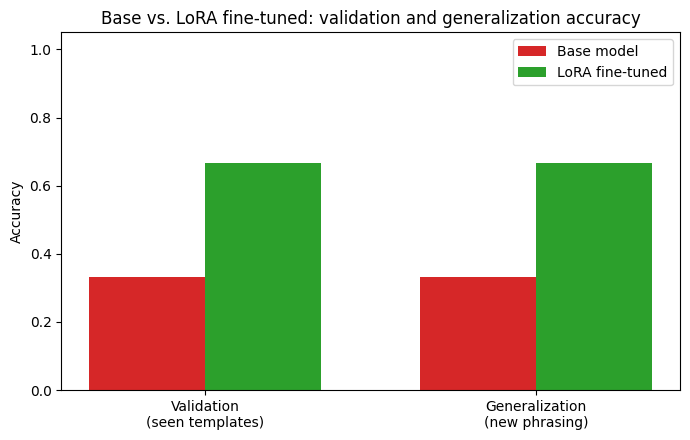

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
categories = ["Validation\n(seen templates)", "Generalization\n(new phrasing)"]
base_scores = [base_val_accuracy, base_gen_accuracy]
lora_scores = [lora_val_accuracy, lora_gen_accuracy]
x = np.arange(len(categories))
width = 0.35
ax.bar(x - width / 2, base_scores, width, label="Base model", color="tab:red")
ax.bar(x + width / 2, lora_scores, width, label="LoRA fine-tuned", color="tab:green")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Base vs. LoRA fine-tuned: validation and generalization accuracy")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "finetuning_comparison.png", dpi=150)
plt.show()

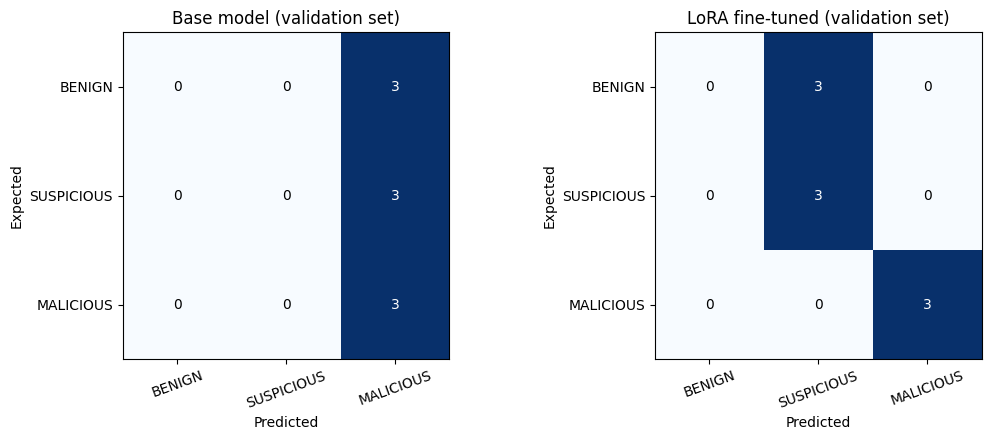

Saved: finetuning_loss.png, finetuning_comparison.png, finetuning_confusion_matrix.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cm, title in zip(axes, [cm_base, cm_lora], ["Base model", "LoRA fine-tuned"]):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(LABELS)))
    ax.set_yticks(range(len(LABELS)))
    ax.set_xticklabels(LABELS, rotation=20)
    ax.set_yticklabels(LABELS)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Expected")
    ax.set_title(f"{title} (validation set)")
    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "finetuning_confusion_matrix.png", dpi=150)
plt.show()

print("Saved: finetuning_loss.png, finetuning_comparison.png, finetuning_confusion_matrix.png")

## Final summary

**The key lesson is that fine-tuning is not automatically the right answer. It changes model behavior by updating parameters, but it requires high-quality data, careful evaluation and lifecycle management. RAG, prompting or a domain-specific foundation model may be a better product decision depending on the problem.**

This notebook fine-tuned a 494M-parameter model with LoRA on 36 synthetic examples -- small enough to run in minutes on a laptop, and exactly for that reason, small enough that its results should be read as a demonstration of the mechanism, not proof of the technique's value on this task. The numbers in Sections 5, 8, and 10 are the actual evidence; whatever they show, the point of this notebook was to build the muscle of asking "did it actually help, and how do I know" every time -- the same discipline notebook 04 applied to a security foundation model and notebook 05 applied to a retrieval layer, now applied to the model's own weights.